# Titanic 竞赛模块 B：数据清洗与特征工程

本 Notebook 是模块 B 的正式交付说明，覆盖：

1. 缺失值处理：`Age`、`Fare`、`Embarked`、`Cabin`
2. 特征构造：称谓、家庭规模、独行、船票前缀、舱位甲板等
3. 分类变量编码与连续变量标准化
4. 交叉验证折内特征选择
5. 无数据泄漏验证与质量测试

**方法约束：**正式交叉验证必须从原始 `train.csv` 开始，并使用完整
`Pipeline`。`model_ready.csv` 是基于全训练集拟合后的快速建模/最终训练便利版，
不能再次用于正式交叉验证评分。

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

from titanic_b_pipeline import (
    RAW_FEATURE_COLUMNS,
    TitanicFeatureEngineer,
    make_model_pipeline,
)

ROOT = Path.cwd()
REPORTS = ROOT / "reports"
DATA = ROOT / "data"
SOURCE = ROOT / "source"

train = pd.read_csv(SOURCE / "train.csv")
test = pd.read_csv(SOURCE / "test.csv")
quality = json.loads((REPORTS / "quality_report.json").read_text(encoding="utf-8"))
print(f"原始训练集：{train.shape}；原始测试集：{test.shape}")

原始训练集：(891, 12)；原始测试集：(418, 11)


## 1. 原始数据与缺失值审计

原始数据不删除行。年龄、票价和登船港口的填补参数全部由训练数据学习；
在交叉验证时，这些参数只从当前训练折学习。

In [2]:
missing = pd.read_csv(REPORTS / "missing_values_before_after.csv")
display(missing.loc[
    (missing.drop(columns="field") != 0).any(axis=1)
].reset_index(drop=True))

,field,train_raw_missing,test_raw_missing,train_clean_missing,test_clean_missing
0,Age,177,86,0,0
1,Cabin,687,327,0,0
2,Embarked,2,0,0,0
3,Fare,0,1,0,0


## 2. 清洗和特征工程规则

- `Age`：依次使用 `Title + Pclass + Sex`、`Title + Pclass`、`Pclass`
  和总体年龄中位数回退。
- `Fare`：按 `Pclass` 中位数填补。
- `Embarked`：用训练折众数填补。
- `Cabin`：不虚构房号，提取 `HasCabin`、`CabinMissing` 和 `CabinDeck`。
- `Title`：从姓名提取称谓，合并 `Mlle/Ms/Mme`，低频称谓归为 `Rare`。
- `TicketPrefix`：规范化船票前缀，训练折中频数少于 10 的归为 `OTHER`。
- 家庭：构造 `FamilySize`、`FamilyGroup` 和 `IsAlone`。

In [3]:
rules = pd.read_csv(REPORTS / "cleaning_rules.csv")
display(rules)

engineer = TitanicFeatureEngineer().fit(train[RAW_FEATURE_COLUMNS])
clean_preview = engineer.transform(train[RAW_FEATURE_COLUMNS]).head()
display(clean_preview)

,step,item,rule,status
0,1,结构校验,严格检查列名、891/418 行、PassengerId 唯一,PASS
1,2,Age,折内按 Title+Pclass+Sex 中位数填补并逐级回退,PASS
2,3,Fare,折内按 Pclass 中位数填补,PASS
3,4,Embarked,折内训练数据众数填补,PASS
4,5,Cabin,不虚构房号；提取 HasCabin/CabinDeck，未知为 U,PASS
5,6,Name/Title,提取称谓；同义词合并；其余归 Rare,PASS
6,7,Ticket,提取前缀；折内计数少于 10 归 OTHER,PASS
7,8,家庭特征,FamilySize、FamilyGroup、IsAlone,PASS
8,9,编码与缩放,折内 One-Hot；Age/Fare 折内 StandardScaler,PASS
9,10,特征选择,折内 SelectKBest；k 由内层 CV 选择,PASS


,PassengerId,Pclass,Sex,SexEncoded,AgeFilled,AgeBand,SibSp,Parch,FamilySize,FamilyGroup,...,CabinDeck,HasCabin,TicketPrefix,SexPclass,AgePclass,NameLength,WomenChildPriority,AgeMissing,FareMissing,CabinMissing
0,1,3,male,0,22.0,Young,1,0,2,Small,...,U,0,A,male_P3,66.0,23,0,0,0,1
1,2,1,female,1,38.0,Middle,1,0,2,Small,...,C,1,PC,female_P1,38.0,51,1,0,0,0
2,3,3,female,1,26.0,Young,0,0,1,Solo,...,U,0,STONO,female_P3,78.0,22,1,0,0,1
3,4,1,female,1,35.0,Young,1,0,2,Small,...,C,1,NONE,female_P1,35.0,44,1,0,0,0
4,5,3,male,0,35.0,Young,0,0,1,Solo,...,U,0,NONE,male_P3,105.0,24,0,0,0,1


## 3. 无泄漏编码、缩放与特征选择

正式评估的数据流如下：

`原始折内训练数据 → 折内填补/特征工程 → 折内 One-Hot 与 StandardScaler
→ 折内 SelectKBest → 模型`

`AgeFilled` 和 `FareFilled` 使用 `StandardScaler`；分类字段由
`OneHotEncoder(handle_unknown="ignore")` 处理。`SelectKBest` 使用互信息，
候选 `k` 值由内层交叉验证选择。

In [4]:
# 这是成员 C 正式建模时应使用的入口；直接接收原始 11 个特征。
pipeline = make_model_pipeline(k=20)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,ticket_prefix_min_count,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaled', ...), ('numeric', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`

## 4. 嵌套交叉验证结果

采用外层 5 折评估、每个外层训练折内再用 4 折选择 `k`。外层分数才是
正式、无偏的验证结果。

In [5]:
nested = pd.read_csv(REPORTS / "nested_cv_results.csv")
display(nested)
print(
    f"外层平均 Accuracy = {quality['nested_outer_accuracy_mean']:.4f} "
    f"± {quality['nested_outer_accuracy_std']:.4f}"
)
print(f"OOF Accuracy = {quality['oof_accuracy']:.4f}")

,outer_fold,train_rows,validation_rows,best_k,inner_best_accuracy,outer_accuracy
0,1,712,179,28,0.831461,0.832402
1,2,713,178,28,0.816262,0.848315
2,3,713,178,all,0.838695,0.792135
3,4,713,178,20,0.828958,0.848315
4,5,713,178,32,0.824689,0.853933


外层平均 Accuracy = 0.8350 ± 0.0226
OOF Accuracy = 0.8350


## 5. 特征数量选择与最终入选特征

,k,cv_accuracy_mean,cv_accuracy_std,train_accuracy_mean,rank,selected
0,20,0.841736,0.016562,0.843149,1,True
1,24,0.837254,0.015144,0.844835,2,False
2,32,0.833896,0.014883,0.844554,3,False
3,28,0.833896,0.013550,0.845396,4,False
4,40,0.830538,0.011287,0.847639,5,False
5,36,0.830525,0.010920,0.847920,6,False
6,all,0.824895,0.017374,0.850167,7,False
7,16,0.819296,0.018673,0.824072,8,False
8,12,0.808053,0.020753,0.806677,9,False
9,8,0.787885,0.018172,0.790682,10,False


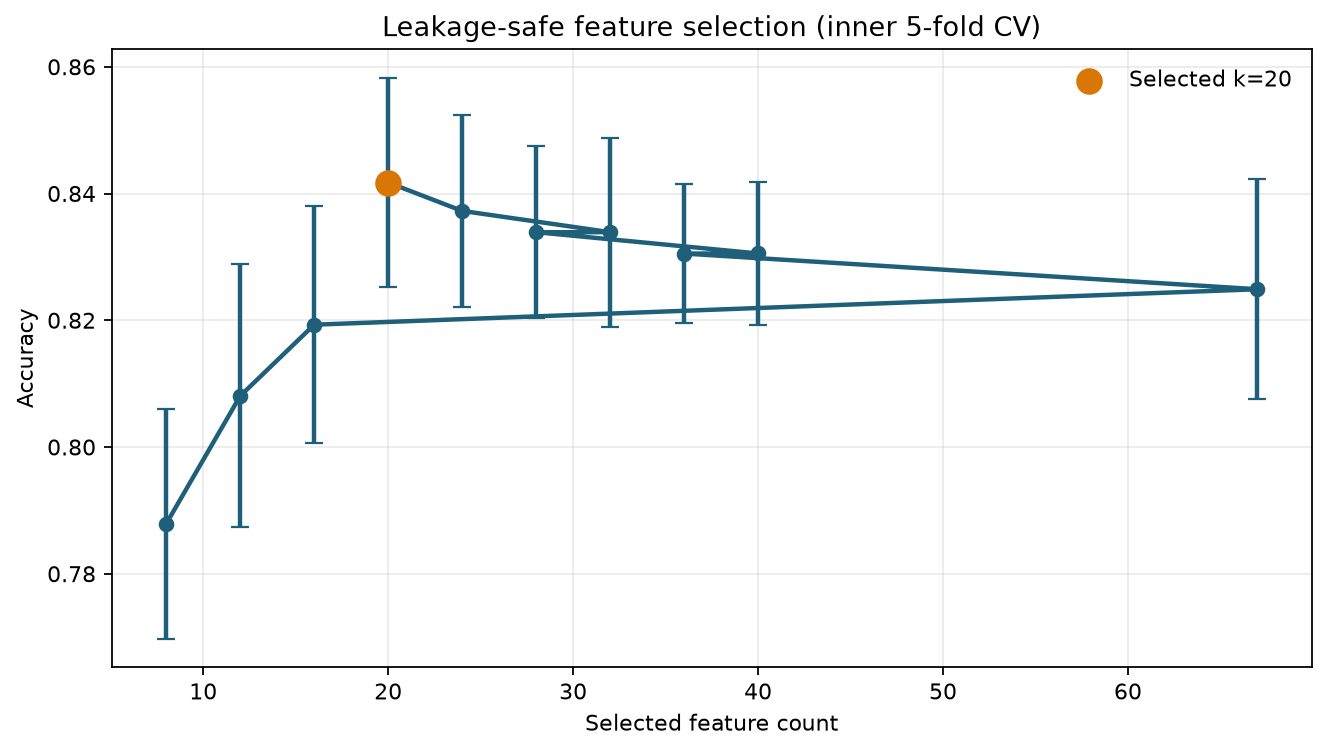

In [6]:
selection = pd.read_csv(REPORTS / "feature_selection_results.csv")
display(selection)
display(Image(filename=str(REPORTS / "feature_selection_cv.png")))

In [7]:
feature_scores = pd.read_csv(REPORTS / "feature_scores.csv")
display(feature_scores.loc[feature_scores["selected"]].reset_index(drop=True))
print(
    f"候选编码特征：{quality['candidate_encoded_feature_count']}；"
    f"最终选择：{quality['selected_feature_count']}；"
    f"最佳 k：{quality['best_k']}"
)

,feature,mutual_information,selected
0,FarePerPerson,0.156441,True
1,WomenChildPriority,0.154068,True
2,FareLog,0.142273,True
3,Sex_male,0.139719,True
4,Sex_female,0.133314,True
5,SexEncoded,0.132158,True
6,FareFilled,0.130742,True
7,Title_Mr,0.128372,True
8,SexPclass_male_P3,0.099358,True
9,AgePclass,0.093915,True


候选编码特征：67；最终选择：20；最佳 k：20


## 6. 清洗后数据和质量验收

`clean.csv` 保留可读的文字类别，适合审计和正式 Pipeline 输入前检查。
`model_ready.csv` 已按全部训练集拟合编码、缩放和选特征，适合快速基线或
最终拟合；它不是正式交叉验证数据源。

In [8]:
train_clean = pd.read_csv(DATA / "Titanic_train_clean.csv")
test_clean = pd.read_csv(DATA / "Titanic_test_clean.csv")
train_ready = pd.read_csv(DATA / "Titanic_train_model_ready.csv")
test_ready = pd.read_csv(DATA / "Titanic_test_model_ready.csv")

summary = pd.DataFrame([
    ["train_clean", *train_clean.shape, int(train_clean.isna().sum().sum())],
    ["test_clean", *test_clean.shape, int(test_clean.isna().sum().sum())],
    ["train_model_ready", *train_ready.shape, int(train_ready.isna().sum().sum())],
    ["test_model_ready", *test_ready.shape, int(test_ready.isna().sum().sum())],
], columns=["dataset", "rows", "columns", "missing_values"])
display(summary)

,dataset,rows,columns,missing_values
0,train_clean,891,28,0
1,test_clean,418,27,0
2,train_model_ready,891,22,0
3,test_model_ready,418,21,0


In [9]:
tests = json.loads((REPORTS / "test_results.json").read_text(encoding="utf-8"))
repro = json.loads(
    (REPORTS / "reproducibility_check.json").read_text(encoding="utf-8")
)
checks = pd.DataFrame({
    "检查项": [
        "总体状态",
        "自动化测试",
        "独立重复运行",
        "清洗后缺失值",
        "训练/测试特征对齐",
        "模型就绪字段均为数值",
        "报告不含个人绝对路径",
    ],
    "结果": [
        quality["status"],
        f"{tests['tests_run'] - tests['failures'] - tests['errors']}/{tests['tests_run']} PASS",
        f"{repro['artifacts_matched']}/{repro['artifacts_checked']} {repro['status']}",
        str(quality["clean_missing_values"]),
        str(quality["train_test_model_features_aligned"]),
        str(quality["all_model_ready_features_numeric"]),
        str(quality["no_absolute_personal_paths_in_deliverables"]),
    ],
})
display(checks)

,检查项,结果
0,总体状态,PASS
1,自动化测试,10/10 PASS
2,独立重复运行,17/17 PASS
3,清洗后缺失值,"{'train': 0, 'test': 0}"
4,训练/测试特征对齐,True
5,模型就绪字段均为数值,True
6,报告不含个人绝对路径,True


## 7. 复现命令

在本目录执行：

```bash
python titanic_b_pipeline.py   --train source/train.csv   --test source/test.csv   --output .
python run_tests.py
```

随机种子固定为 42。输入文件哈希和全部填补参数记录在
`reports/preprocessing_parameters.json`。